In [1]:
# pip install pandas nltk spacy scikit-learn matplotlib
# python -m spacy download en_core_web_sm

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

import spacy
from spacy.matcher import PhraseMatcher

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english'))

In [3]:
df = pd.read_csv("Resume.csv")

df['Category'] = df['Category'].str.strip().str.upper()
print(df.shape)
print(df['Category'].value_counts())
df.head(3)

(2484, 4)
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in text.split() if w not in stop_words]
    return ' '.join(tokens)

df['Cleaned_Resume'] = df['Resume_str'].apply(clean_text)

In [5]:
MASTER_SKILLS = [
    # Tech / IT
    "python", "sql", "java", "c++", "aws", "azure", "linux", "networking",
    "cybersecurity", "docker", "kubernetes", "cloud", "system administration",
    "database management", "troubleshooting", "windows server", "active directory",
    "machine learning", "data visualization", "power bi", "tableau", "excel", "pandas",
    # Business / Sales
    "sales", "negotiation", "crm", "lead generation", "market research",
    "business development", "account management", "client relations",
    # HR
    "recruitment", "onboarding", "employee relations", "payroll", "hr policies",
    "performance management", "talent acquisition",
    # Design
    "photoshop", "illustrator", "figma", "ui/ux", "adobe creative suite", "branding",
    # Finance / Accounting
    "accounting", "financial analysis", "budgeting", "auditing", "taxation",
    "quickbooks", "forecasting",
    # Soft skills (common across all roles)
    "communication", "leadership", "teamwork", "project management",
    "problem solving", "stakeholder reporting", "presentation", "a/b testing"
]

matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
matcher.add("SKILLS", [nlp.make_doc(s) for s in MASTER_SKILLS])

def extract_skills(text):
    doc = nlp(text)
    matches = matcher(doc)
    return set(doc[start:end].text.lower() for _, start, end in matches)

In [6]:
def build_job_profile(job_description, must_have_skills=None):
    """
    Parses a job description and returns:
    - required_skills: all skills mentioned
    - weights: dict mapping skill -> weight (must-have=2.0, nice-to-have=1.0)
    """
    cleaned = clean_text(job_description)
    required_skills = extract_skills(job_description)
    must_have_skills = set(s.lower() for s in (must_have_skills or []))

    weights = {
        skill: 2.0 if skill in must_have_skills else 1.0
        for skill in required_skills
    }
    return cleaned, required_skills, weights

In [7]:
def weighted_skill_overlap(candidate_skills, required_skills, weights):
    if not required_skills:
        return 0.0
    matched_weight = sum(weights[s] for s in (candidate_skills & required_skills))
    total_weight = sum(weights.values())
    return matched_weight / total_weight

def compute_tfidf_similarity(cleaned_job, cleaned_resumes):
    documents = [cleaned_job] + cleaned_resumes
    vectorizer = TfidfVectorizer(max_features=5000)
    tfidf_matrix = vectorizer.fit_transform(documents)
    job_vector = tfidf_matrix[0:1]
    resume_vectors = tfidf_matrix[1:]
    return cosine_similarity(job_vector, resume_vectors)[0]

In [8]:
def screen_resumes(resume_df, job_description, must_have_skills=None,
                    sim_weight=0.6, skill_weight=0.4):
    cleaned_job, required_skills, weights = build_job_profile(job_description, must_have_skills)

    resume_df = resume_df.copy()
    resume_df['Extracted_Skills'] = resume_df['Resume_str'].apply(extract_skills)
    resume_df['TFIDF_Similarity'] = compute_tfidf_similarity(
        cleaned_job, resume_df['Cleaned_Resume'].tolist()
    )
    resume_df['Skill_Overlap'] = resume_df['Extracted_Skills'].apply(
        lambda s: weighted_skill_overlap(s, required_skills, weights)
    )
    resume_df['Final_Score'] = (
        sim_weight * resume_df['TFIDF_Similarity'] +
        skill_weight * resume_df['Skill_Overlap']
    )
    resume_df['Matched_Skills'] = resume_df['Extracted_Skills'].apply(lambda s: s & required_skills)
    resume_df['Missing_Skills'] = resume_df['Extracted_Skills'].apply(lambda s: required_skills - s)

    ranked = resume_df.sort_values('Final_Score', ascending=False).reset_index(drop=True)
    ranked.insert(0, 'Rank', ranked.index + 1)

    return ranked[['Rank', 'ID', 'Category', 'TFIDF_Similarity', 'Skill_Overlap',
                    'Final_Score', 'Matched_Skills', 'Missing_Skills']], required_skills

In [10]:
def explain_candidate(row):
    score = row['Final_Score']
    verdict = "a strong match" if score >= 0.4 else "a partial match" if score >= 0.2 else "a weak match"
    matched = ", ".join(sorted(row['Matched_Skills'])) if row['Matched_Skills'] else "none"
    missing = ", ".join(sorted(row['Missing_Skills'])) if row['Missing_Skills'] else "None"
    return (f"Candidate {row['ID']} ({row['Category']}) is {verdict} "
            f"(score: {score:.2f}).\n  Matched: {matched}\n  Missing: {missing}")

def print_summary(ranked_df, top_n=5):
    print("=== Candidate Screening Summary ===\n")
    for _, row in ranked_df.head(top_n).iterrows():
        print(explain_candidate(row))
        print()

In [11]:
def plot_ranking(ranked_df, top_n=10, title="Candidate Ranking"):
    top = ranked_df.head(top_n)
    plt.figure(figsize=(9, 6))
    bars = plt.barh(top['ID'].astype(str), top['Final_Score'], color="#4C72B0")
    plt.xlabel("Final Fit Score")
    plt.title(title)
    plt.gca().invert_yaxis()
    for bar, score in zip(bars, top['Final_Score']):
        plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                  f"{score:.2f}", va='center')
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

### Running It for IT Role

In [12]:
it_resumes = df[df['Category'] == 'INFORMATION-TECHNOLOGY']

it_job_description = """
We are looking for an IT professional with strong skills in Python, SQL, networking,
cloud platforms (AWS or Azure), Linux, cybersecurity, and troubleshooting. Experience
with system administration and database management is required. Communication and
problem solving skills are essential.
"""

it_ranking, it_required = screen_resumes(
    it_resumes,
    it_job_description,
    must_have_skills=["python", "sql", "networking"]   # marked as must-have -> weighted higher
)

print("Required skills:", it_required)
it_ranking.head(10)

Required skills: {'azure', 'networking', 'linux', 'system administration', 'troubleshooting', 'python', 'sql', 'aws', 'database management', 'communication', 'problem solving', 'cybersecurity', 'cloud'}


,Rank,ID,Category,TFIDF_Similarity,Skill_Overlap,Final_Score,Matched_Skills,Missing_Skills
0,1,20824105,INFORMATION-TECHNOLOGY,0.176960,0.5000,0.306176,"{networking, linux, python, aws, communication...","{azure, system administration, troubleshooting..."
1,2,46260230,INFORMATION-TECHNOLOGY,0.094910,0.5625,0.281946,"{networking, system administration, linux, tro...","{azure, python, sql, aws, cloud}"
2,3,10089434,INFORMATION-TECHNOLOGY,0.093255,0.5000,0.255953,"{azure, networking, linux, troubleshooting, sq...","{system administration, python, database manag..."
3,4,17688766,INFORMATION-TECHNOLOGY,0.081824,0.5000,0.249094,"{networking, troubleshooting, sql, communicati...","{azure, linux, system administration, python, ..."
4,5,18067556,INFORMATION-TECHNOLOGY,0.077668,0.5000,0.246601,"{azure, linux, python, aws, sql, cloud}","{networking, system administration, troublesho..."
5,6,29051656,INFORMATION-TECHNOLOGY,0.105235,0.4375,0.238141,"{linux, troubleshooting, communication, aws, s...","{azure, networking, system administration, pyt..."
6,7,18301617,INFORMATION-TECHNOLOGY,0.086614,0.4375,0.226968,"{networking, linux, troubleshooting, communica...","{azure, system administration, python, databas..."
7,8,51639418,INFORMATION-TECHNOLOGY,0.079433,0.4375,0.222660,"{networking, linux, communication, sql, cloud}","{azure, system administration, troubleshooting..."
8,9,81761658,INFORMATION-TECHNOLOGY,0.072183,0.4375,0.218310,"{networking, linux, troubleshooting, communica...","{azure, system administration, python, aws, sq..."
9,10,36434348,INFORMATION-TECHNOLOGY,0.141644,0.3125,0.209987,"{system administration, troubleshooting, commu...","{azure, networking, linux, python, aws, databa..."


=== Candidate Screening Summary ===

Candidate 20824105 (INFORMATION-TECHNOLOGY) is a partial match (score: 0.31).
  Matched: aws, cloud, communication, linux, networking, python
  Missing: azure, cybersecurity, database management, problem solving, sql, system administration, troubleshooting

Candidate 46260230 (INFORMATION-TECHNOLOGY) is a partial match (score: 0.28).
  Matched: communication, cybersecurity, database management, linux, networking, problem solving, system administration, troubleshooting
  Missing: aws, azure, cloud, python, sql

Candidate 10089434 (INFORMATION-TECHNOLOGY) is a partial match (score: 0.26).
  Matched: azure, cloud, linux, networking, sql, troubleshooting
  Missing: aws, communication, cybersecurity, database management, problem solving, python, system administration

Candidate 17688766 (INFORMATION-TECHNOLOGY) is a partial match (score: 0.25).
  Matched: communication, cybersecurity, networking, problem solving, sql, troubleshooting
  Missing: aws, azur

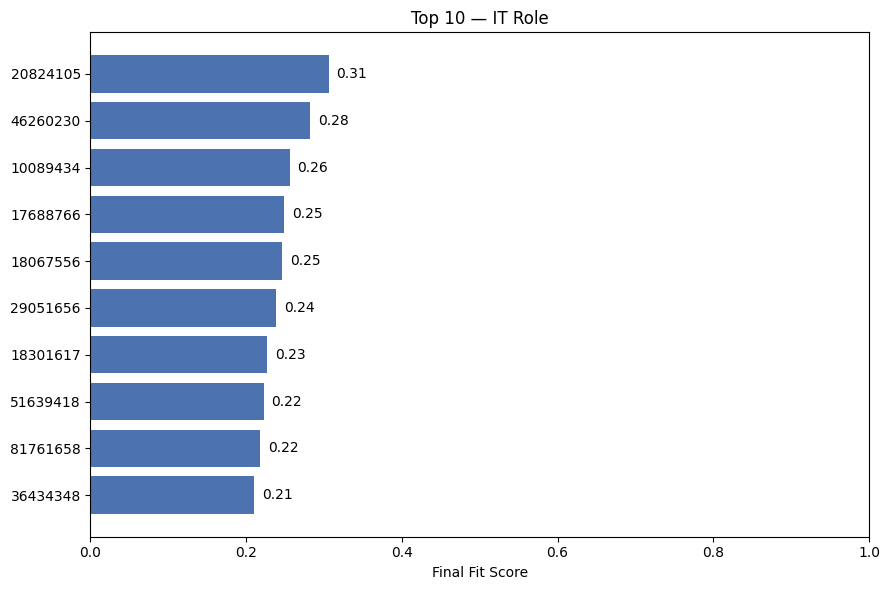

In [14]:
print_summary(it_ranking, top_n=5)
plot_ranking(it_ranking, top_n=10, title="Top 10 — IT Role")

### Running it for Sales Role

=== Candidate Screening Summary ===

Candidate 26425074 (SALES) is a partial match (score: 0.33).
  Matched: account management, business development, communication, crm, negotiation, sales
  Missing: client relations, lead generation, presentation

Candidate 15765660 (SALES) is a partial match (score: 0.28).
  Matched: account management, communication, crm, lead generation, sales
  Missing: business development, client relations, negotiation, presentation

Candidate 13178604 (SALES) is a partial match (score: 0.27).
  Matched: account management, lead generation, negotiation, sales
  Missing: business development, client relations, communication, crm, presentation

Candidate 34303500 (SALES) is a partial match (score: 0.24).
  Matched: communication, negotiation, presentation, sales
  Missing: account management, business development, client relations, crm, lead generation

Candidate 38087844 (SALES) is a partial match (score: 0.23).
  Matched: account management, client relations, c

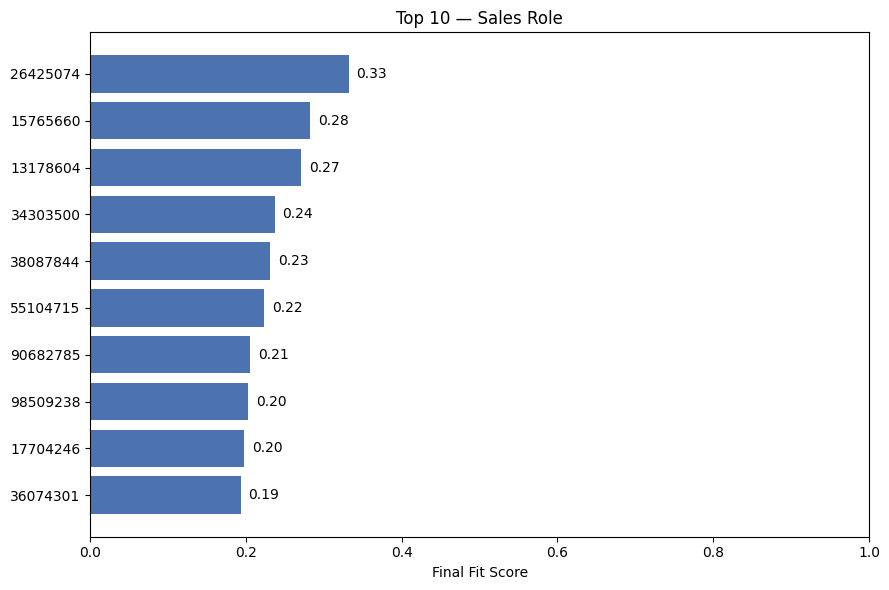

In [15]:
sales_resumes = df[df['Category'] == 'SALES']

sales_job_description = """
Looking for a Sales professional with strong negotiation, lead generation, and CRM skills.
Experience in business development, client relations, and account management is required.
Strong communication and presentation abilities are a must.
"""

sales_ranking, sales_required = screen_resumes(
    sales_resumes,
    sales_job_description,
    must_have_skills=["negotiation", "crm", "lead generation"]
)

print_summary(sales_ranking, top_n=5)
plot_ranking(sales_ranking, top_n=10, title="Top 10 — Sales Role")

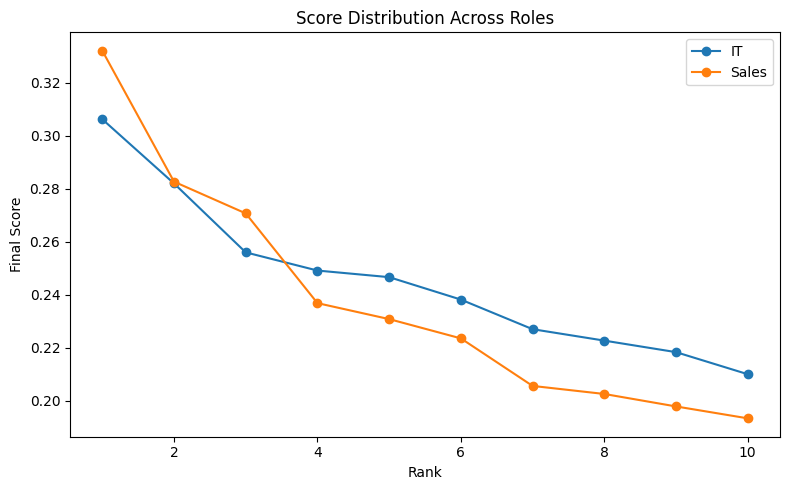

In [16]:
def compare_top_scores_across_roles(results_dict):
    """results_dict = {'Role Name': ranked_df, ...}"""
    plt.figure(figsize=(8, 5))
    for role, ranked_df in results_dict.items():
        plt.plot(range(1, len(ranked_df)+1), ranked_df['Final_Score'].values,
                  marker='o', label=role)
    plt.xlabel("Rank")
    plt.ylabel("Final Score")
    plt.title("Score Distribution Across Roles")
    plt.legend()
    plt.tight_layout()
    plt.show()

compare_top_scores_across_roles({
    "IT": it_ranking.head(10),
    "Sales": sales_ranking.head(10)
})